In [1]:
import pandas as pd
import pickle
import os
from tqdm import tqdm

Use fastas and run mmseq2 ourselves

In [2]:
fasta_dirs = {
    "PPI": "/n/holyscratch01/mzitnik_lab/afang/raw_QBioLiP_06_2024/PPI/nonredund_fasta",
    "PRNA": "/n/holyscratch01/mzitnik_lab/afang/raw_QBioLiP_06_2024/PRNA/nonredund_fasta",
    "PDNA": "/n/holyscratch01/mzitnik_lab/afang/raw_QBioLiP_06_2024/PDNA/nonredund_fasta",
    "RNAL": "/n/holyscratch01/mzitnik_lab/afang/raw_QBioLiP_06_2024/RNAL/nonredund_fasta",
    "PL": "/n/holyscratch01/mzitnik_lab/afang/raw_QBioLiP_06_2024/PL/nonredund_fasta",
    "PIII": "/n/holyscratch01/mzitnik_lab/afang/raw_QBioLiP_06_2024/PIII/nonredund_fasta",
    "Pion": "/n/holyscratch01/mzitnik_lab/afang/raw_QBioLiP_06_2024/Pion/nonredund_fasta",
}

In [3]:
combined_fastas = {}
for modality, fasta_dir in fasta_dirs.items():
    if os.path.exists(f"/n/holyscratch01/mzitnik_lab/afang/raw_QBioLiP_06_2024/{modality}/nonredund.fasta"):
        with open(f"/n/holyscratch01/mzitnik_lab/afang/raw_QBioLiP_06_2024/{modality}/nonredund.fasta", 'r') as f:
            all_fastas = f.readlines()
    else:
        all_fastas = []
        for fasta_file in tqdm(os.listdir(fasta_dir), total=len(os.listdir(fasta_dir)), desc=f"Processing {modality}"):
            with open(os.path.join(fasta_dir, fasta_file), 'r') as f:
                lines = f.readlines()
                all_fastas.extend(lines)
        all_fastas = [line if line.endswith('\n') else line + '\n' for line in all_fastas]
    combined_fastas[modality] = all_fastas

In [5]:
# remove any PDBs that are involved in downstream finetuning 
exclude_pdbs = []

pdbbind_dir = "/n/holylabs/LABS/mzitnik_lab/Users/afang/GET/datasets/PDBBind/processed_PS_300/identity30/"
for split in ["test"]: #"train", "valid", 
    with open(f"{pdbbind_dir}/{split}.pkl", "rb") as f:
        data = pickle.load(f)
    pdbs = [item['id'] for item in data]
    print(f"PL30: {len(pdbs)}")
    exclude_pdbs.extend(pdbs)

# pdbbind_dir = "/n/holylabs/LABS/mzitnik_lab/Users/afang/GET/datasets/PDBBind/processed_PS_300/identity60/"
# for split in ["train", "valid", "test"]:
#     with open(f"{pdbbind_dir}/{split}.pkl", "rb") as f:
#         data = pickle.load(f)
#     pdbs = [item['id'] for item in data]
#     print(f"PL60: {len(pdbs)}")
#     exclude_pdbs.extend(pdbs)

with open("/n/holylabs/LABS/mzitnik_lab/Users/afang/GET/datasets/PPA/processed/new_split_30/test.pkl", "rb") as f:
    ppa_data = pickle.load(f)
ppa_pdbs = [item['id'] for item in ppa_data]
print(f"PPA test: {len(ppa_pdbs)}")
exclude_pdbs.extend(ppa_pdbs)

# duplicates on PDB ID, not sure if I can trust it
# build benchmark just of PPA PDBbind data split by 30% sequence identity on all chains
# with open("/n/holylabs/LABS/mzitnik_lab/Users/afang/GET/datasets/PPA/processed/PPAB_V2.pkl", "rb") as f:
#     ppa_data = pickle.load(f)
# ppa_pdbs = [item['id'] for item in ppa_data]
# print(f"PPA test: {len(ppa_pdbs)}")
# exclude_pdbs.extend(ppa_pdbs)

# plinder = pd.read_csv("/n/holylabs/LABS/mzitnik_lab/Users/afang/GET/case_studies/plinder/plinder_2024-06_v2_index_has_ba_remove_shared_binding_ids.csv")
# plinder_pdbs = list(plinder['entry_pdb_id'].unique())
# print(f"PLINDER: {len(plinder_pdbs)}")
# exclude_pdbs.extend(plinder_pdbs)

# merck_fep = ['5hnb', '4r1y', '3l9h', '8ck3', '5tbm', '6hvi', '5ehr', '4pv0', '4ui5'] # https://pubs.acs.org/doi/10.1021/ja512751q
# exclude_pdbs.extend(merck_fep)

# schrodinger_fep = ["4djw", "1h1q", "2gmx", "4hw3", "3fly", "2qbs", "2zff", "4gih"] # https://pubs.acs.org/doi/10.1021/ja512751q 
# exclude_pdbs.extend(schrodinger_fep)

for idx, item in enumerate(exclude_pdbs):
    if len(item) != 4:
        exclude_pdbs[idx] = item[:4]

exclude_pdbs = set(exclude_pdbs)

PL30: 487
PPA test: 107


In [6]:
print(len(exclude_pdbs))

594


In [115]:
import requests
exclude_fastas = []
fasta_url = "https://www.rcsb.org/fasta/entry/"
for pdb in tqdm(exclude_pdbs, desc="Downloading fastas", total=len(exclude_pdbs)):
    r = requests.get(fasta_url + pdb.upper())
    if r.status_code == 200:
        exclude_fastas.append(r.text)
    else:
        print(f"Failed to download {pdb}")

In [116]:
with open("exclude_pdbs.fasta", "w") as f:
    f.writelines(exclude_fastas)

## Split PDBbind PPA into a 30% sequence split

In [55]:
ppa_clusters = pd.read_csv("/n/holylabs/LABS/mzitnik_lab/Users/afang/GET/case_studies/frequency_split/PDBbind_PPA_only_cluster.tsv", sep="\t", names=["cluster", "pdb"])
ppa_clusters['pdb'] = ppa_clusters['pdb'].apply(lambda x: x.split("_")[0].lower())
ppa_clusters['cluster'] = ppa_clusters['cluster'].apply(lambda x: x.split("_")[0].lower())

In [56]:
with open("/n/holylabs/LABS/mzitnik_lab/Users/afang/GET/datasets/PPA/processed/PDBbind.pkl", "rb") as f:
    ppa_data = pickle.load(f)

ppa_data_ids = [item['id'][:4] for item in ppa_data]

In [59]:
len(ppa_data_ids)

2499

In [60]:
ppa_clusters

,cluster,pdb
0,3ddc,3ddc
1,5wb7,5wb7
2,4i2x,4i2x
3,2ajf,2ajf
4,2ajf,2ajf
...,...,...
6052,6iwd,6iwd
6053,6fc2,6fc2
6054,1yd8,1yd8
6055,1yd8,1wr6


In [72]:
import networkx as nx

G = nx.Graph()
for row in ppa_clusters.itertuples():
    G.add_edge(row.cluster, row.pdb)

disconnected_ppa_clusters = list(nx.connected_components(G))
print(len(disconnected_ppa_clusters))

507


In [106]:
import random
disconnected_ppa_clusters = list(nx.connected_components(G))
random.seed(8291)
random.shuffle(disconnected_ppa_clusters)

train_clusters = disconnected_ppa_clusters[:int(len(disconnected_ppa_clusters) * 0.8)]
valid_clusters = disconnected_ppa_clusters[int(len(disconnected_ppa_clusters) * 0.8):int(len(disconnected_ppa_clusters) * 0.9)]
test_clusters = disconnected_ppa_clusters[int(len(disconnected_ppa_clusters) * 0.9):]

train_pdbs = set([item for sublist in train_clusters for item in sublist])
valid_pdbs = set([item for sublist in valid_clusters for item in sublist])
test_pdbs = set([item for sublist in test_clusters for item in sublist])

train_ids = list(set([x for x in ppa_data_ids if x[:4] in train_pdbs]))
valid_ids = list(set([x for x in ppa_data_ids if x[:4] in valid_pdbs]))
test_ids = list(set([x for x in ppa_data_ids if x[:4] in test_pdbs]))

print(f"Train: num pdbs: {len(train_pdbs)}, num ids: {len(train_ids)}")
print(f"Valid: num pdbs: {len(valid_pdbs)}, num ids: {len(valid_ids)}")
print(f"Test: num pdbs: {len(test_pdbs)}, num ids: {len(test_ids)}")

Train: num pdbs: 2283, num ids: 2283
Valid: num pdbs: 109, num ids: 109
Test: num pdbs: 107, num ids: 107


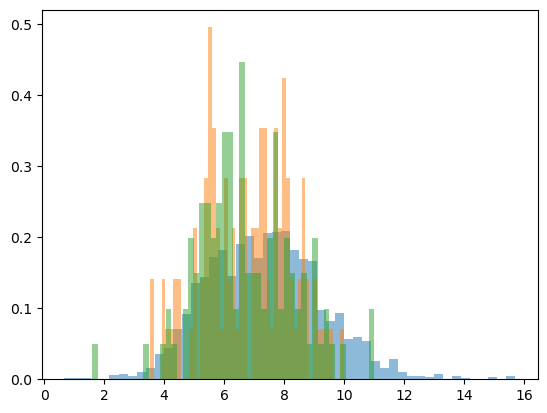

In [110]:
train_ppa = [item for item in ppa_data if item['id'] in train_ids]
valid_ppa = [item for item in ppa_data if item['id'] in valid_ids]
test_ppa = [item for item in ppa_data if item['id'] in test_ids]

import matplotlib.pyplot as plt
train_ppa_affinity = [item['affinity']['neglog_aff'] for item in train_ppa]
valid_ppa_affinity = [item['affinity']['neglog_aff'] for item in valid_ppa]
test_ppa_affinity = [item['affinity']['neglog_aff'] for item in test_ppa]
plt.hist(train_ppa_affinity, bins=50, alpha=0.5, density=True, label='train')
plt.hist(valid_ppa_affinity, bins=50, alpha=0.5, density=True, label='valid')
plt.hist(test_ppa_affinity, bins=50, alpha=0.5, density=True, label='test')
plt.show()

In [111]:
with open("/n/holylabs/LABS/mzitnik_lab/Users/afang/GET/datasets/PPA/processed/new_split_30/train.pkl", "wb") as f:
    pickle.dump(train_ppa, f)
with open("/n/holylabs/LABS/mzitnik_lab/Users/afang/GET/datasets/PPA/processed/new_split_30/valid.pkl", "wb") as f:
    pickle.dump(valid_ppa, f)
with open("/n/holylabs/LABS/mzitnik_lab/Users/afang/GET/datasets/PPA/processed/new_split_30/test.pkl", "wb") as f:
    pickle.dump(test_ppa, f)

## Handle missing PPIs

In [92]:
with open("/n/holystore01/LABS/mzitnik_lab/Lab/afang/QBioLiP/QBioLiP-06-2024-torsion/PL_nonredund.pkl", 'rb') as f:
    data = pickle.load(f)
data_ids = [x['id'] for x in data]

KeyboardInterrupt: 

In [91]:
# Some of the fastas are missing chains. Double check and rewrite the missing ones. 
# PPI script
# seq_ids = combined_fastas['PPI'][0::2]
# seq_ids = [x[1:].strip() for x in seq_ids]
# seq_ids = set(seq_ids)

# for item in data_ids:
#     pdb_id, assembly_id, ch1, ch2 = item.split('_')
#     if f'{pdb_id}_{assembly_id}_{ch1}' not in seq_ids:
#         print(f"missing {item}")
#     if f'{pdb_id}_{assembly_id}_{ch2}' not in seq_ids:
#         print(f"missing {item}")

# non PPI script
seq_ids = combined_fastas['PL'][0::2]
seq_ids = [x[1:].strip() for x in seq_ids]
seq_ids = ['_'.join(x.split('_')[:2]) for x in seq_ids]
seq_ids = set(seq_ids)

for item in data_ids:
    pdb_assembly_id = item.split(".pdb")[0]
    if pdb_assembly_id not in seq_ids:
        print(f"missing {item}")

In [ ]:
# for any missing fastas rewrite them
from Bio import PDB
from Bio.SeqUtils import seq1
from Bio.Seq import Seq
from Bio.SeqRecord import SeqRecord
from Bio import SeqIO
from Bio.SeqIO.FastaIO import FastaWriter

def pdb_to_fasta(pdb_filename, fasta_filename):
    structure_id = os.path.basename(pdb_filename).split('.')[0]

    # Create a PDB parser
    parser = PDB.PDBParser(QUIET=True)

    # Parse the structure
    structure = parser.get_structure("protein_structure", pdb_filename)

    # Open the FASTA file for writing
    with open(fasta_filename, "w") as output_file:
        for model in structure:
            for chain in model:
                sequence = ""
                for residue in chain:
                    # Ensure the residue is an amino acid
                    if PDB.is_aa(residue, standard=True):
                        sequence += seq1(residue.get_resname())
                
                # Create a sequence record for the chain
                seq_record = SeqRecord(
                    Seq(sequence),
                    id=f"{structure_id}_{chain.id}",
                    description=f"Chain {chain.id}"
                )

                # Write to the output file without wrapping
                output_file.write(f">{seq_record.id}\n")
                output_file.write(f"{seq_record.seq}\n")


# Example usage
pdb_filename = "/n/holyscratch01/mzitnik_lab/afang/raw_QBioLiP_06_2024/PPI/nonredund_pdb/1bth_1.pdb"
fasta_filename = "/n/holyscratch01/mzitnik_lab/afang/raw_QBioLiP_06_2024/PPI/nonredund_fasta/1bth_1.fasta"
pdb_to_fasta(pdb_filename, fasta_filename)

## Run mmseq2

In [120]:
for modality in combined_fastas.keys():
    with open(f"/n/holyscratch01/mzitnik_lab/afang/raw_QBioLiP_06_2024/{modality}/nonredund.fasta", 'w') as f:
        f.writelines(combined_fastas[modality])
    if modality.startswith('P'): # make sure to cluster with proteins to be excluded
        with open(f"/n/holyscratch01/mzitnik_lab/afang/raw_QBioLiP_06_2024/{modality}/nonredund_with_exclude.fasta", 'w') as f:
            f.writelines(combined_fastas[modality]+exclude_fastas)
    print(f"Saved {modality} fasta")

Saved PPI fasta
Saved PRNA fasta
Saved PDNA fasta
Saved RNAL fasta
Saved PL fasta
Saved PIII fasta
Saved Pion fasta


Run mmseq
`./mmseqs easy-cluster /n/holyscratch01/mzitnik_lab/afang/raw_QBioLiP_06_2024/PPI/nonredund.fasta /n/holyscratch01/mzitnik_lab/afang/raw_QBioLiP_06_2024/PPI/clusters /n/holyscratch01/mzitnik_lab/afang/tmp --cluster-mode 1 --min-seq-id 0.3 -c 0.8 -s 8`

## Split PPIs
Let test set be those that have sequence overlap > 30% to the exclude set.
Make sure that for the PPIs A-B and C-D, A-B belong to different clusters if A does not overlap in sequence by 30% to C or D and B does not overlap in sequence by 30% to C or D. Use a graph to find disconnected components and split them into different train/val/test sets.

In [7]:
with open("/n/holystore01/LABS/mzitnik_lab/Lab/afang/QBioLiP/QBioLiP-06-2024-torsion/PP_nonredund_fixed_ids.pkl", 'rb') as f:
    data = pickle.load(f)
data_ids = [x['id'] for x in data]

In [138]:
clusters = pd.read_csv("/n/holyscratch01/mzitnik_lab/afang/raw_QBioLiP_06_2024/PPI/clusters_30_with_exclude_cluster.tsv", sep='\t', names=['rep_id', 'seq_id'])
clusters.set_index('seq_id', inplace=True)

In [139]:
import networkx as nx
G = nx.Graph()

seq_ids = set(clusters.index.values)
for item in data_ids:
    pdb_id, assembly_id, ch1, ch2 = item.split('_')
    if f'{pdb_id}_{assembly_id}_{ch1}' not in seq_ids:
        print(f"missing {item}")
    else:
        rep_id = clusters.loc[f'{pdb_id}_{assembly_id}_{ch1}']['rep_id']
        G.add_edge(item, rep_id)
    if f'{pdb_id}_{assembly_id}_{ch2}' not in seq_ids:
        print(f"missing {item}")
    else:
        rep_id = clusters.loc[f'{pdb_id}_{assembly_id}_{ch2}']['rep_id']
        G.add_edge(item, rep_id)

for row in clusters.itertuples():
    G.add_edge(row.Index, row.rep_id)

In [140]:
connected_components = nx.connected_components(G)
print(len(list(connected_components)), len(data_ids), len(clusters['rep_id'].unique()))

12435 124541 19173


In [141]:
exclude_pdbs = []
with open("/n/holylabs/LABS/mzitnik_lab/Users/afang/GET/datasets/PPA/processed/new_split_30/test.pkl", "rb") as f:
    ppa_data = pickle.load(f)
ppa_pdbs = [item['id'] for item in ppa_data]
print(f"PPA train: {len(ppa_pdbs)}")
exclude_pdbs.extend(ppa_pdbs)

keep_components = []
exclude_components = []
for i, component in enumerate(nx.connected_components(G)):
    component_ids = set(x.split('_')[0].lower() for x in component)
    if component_ids.intersection(exclude_pdbs):
        exclude_components.append(component)
    else:
        keep_components.append(component)
print("Num components to exclude", len(exclude_components))
print("Num components to keep", len(keep_components))

Num components to exclude 117
Num components to keep 12318


In [142]:
import random
random.seed(42)
random.shuffle(keep_components)

train_components = keep_components[:int(0.9*len(keep_components))]
valid_components = keep_components[int(0.9*len(keep_components)):]

set_data_ids = set(data_ids)
train_data_ids = sum([list(x.intersection(set_data_ids)) for x in train_components], [])
valid_data_ids = sum([list(x.intersection(set_data_ids)) for x in valid_components], [])
test_data_ids = sum([list(x.intersection(set_data_ids)) for x in exclude_components], [])

print("Train: components", len(train_components), "data_ids", len(train_data_ids))
print("Valid: components", len(valid_components), "data_ids", len(valid_data_ids))
print("Test/Exclude: components", len(exclude_components), "data_ids", len(test_data_ids))

Train: components 11086 data_ids 83153
Valid: components 1232 data_ids 8776
Test/Exclude: components 117 data_ids 32612


In [143]:
train_data_ids = set(train_data_ids)
valid_data_ids = set(valid_data_ids)
test_data_ids = set(test_data_ids)

train_data = [x for x in data if x['id'] in train_data_ids]
valid_data = [x for x in data if x['id'] in valid_data_ids]
test_data = [x for x in data if x['id'] in test_data_ids]
print(f"Train: {len(train_data)}, Valid: {len(valid_data)}, Test: {len(test_data)}")

Train: 83153, Valid: 8776, Test: 32612


In [144]:
with open("/n/holystore01/LABS/mzitnik_lab/Lab/afang/QBioLiP/sequence_30_split/PP_train.pkl", 'wb') as f:
    pickle.dump(train_data, f)
with open("/n/holystore01/LABS/mzitnik_lab/Lab/afang/QBioLiP/sequence_30_split/PP_valid.pkl", 'wb') as f:
    pickle.dump(valid_data, f)
with open("/n/holystore01/LABS/mzitnik_lab/Lab/afang/QBioLiP/sequence_30_split/PP_test.pkl", 'wb') as f:
    pickle.dump(test_data, f)

## Split PL

In [175]:
with open("/n/holystore01/LABS/mzitnik_lab/Lab/afang/QBioLiP/QBioLiP-06-2024-torsion/PL_nonredund.pkl", 'rb') as f:
    data = pickle.load(f)
data_ids = [x['id'] for x in data]

In [153]:
clusters = pd.read_csv("/n/holyscratch01/mzitnik_lab/afang/raw_QBioLiP_06_2024/PL/clusters_30_with_exclude_cluster.tsv", sep='\t', names=['rep_id', 'seq_id'])
clusters.set_index('seq_id', inplace=True)

In [154]:
import networkx as nx
G = nx.Graph()

seq_ids = set(clusters.index.values)
for item in data_ids:
    item_prefix = item.split('.pdb')[0]

    matching_seq_ids = [x for x in seq_ids if x.startswith(item_prefix)]

    if len(matching_seq_ids) == 0:
        print(f"missing {item}")
    else:
        for seq_id in matching_seq_ids:
            rep_id = clusters.loc[seq_id]['rep_id']
            G.add_edge(item, rep_id)

for row in clusters.itertuples():
    G.add_edge(row.Index, row.rep_id)

In [155]:
connected_components = nx.connected_components(G)
print(len(list(connected_components)), len(data_ids), len(clusters['rep_id'].unique()))

8178 119017 13616


In [161]:
exclude_pdbs = []

pdbbind_dir = "/n/holylabs/LABS/mzitnik_lab/Users/afang/GET/datasets/PDBBind/processed_PS_300/identity30/"
for split in ["test"]: #"train", "valid", 
    with open(f"{pdbbind_dir}/{split}.pkl", "rb") as f:
        data = pickle.load(f)
    pdbs = [item['id'] for item in data]
    print(f"PL30: {len(pdbs)}")
    exclude_pdbs.extend(pdbs)

keep_components = []
exclude_components = []
for i, component in enumerate(nx.connected_components(G)):
    component_ids = set(x.split('_')[0].lower() for x in component)
    if component_ids.intersection(exclude_pdbs):
        exclude_components.append(component)
    else:
        keep_components.append(component)
print("Num components to exclude", len(exclude_components))
print("Num components to keep", len(keep_components))

PL30: 487
Num components to exclude 41
Num components to keep 8137


In [169]:
import random
random.seed(42)
random.shuffle(keep_components)

train_components = keep_components[:int(0.9*len(keep_components))]
valid_components = keep_components[int(0.9*len(keep_components)):]

set_data_ids = set(data_ids)
train_data_ids = sum([list(x.intersection(set_data_ids)) for x in train_components], [])
valid_data_ids = sum([list(x.intersection(set_data_ids)) for x in valid_components], [])
test_data_ids = sum([list(x.intersection(set_data_ids)) for x in exclude_components], [])

print("Train: components", len(train_components), "data_ids", len(train_data_ids))
print("Valid: components", len(valid_components), "data_ids", len(valid_data_ids))
print("Test/Exclude: components", len(exclude_components), "data_ids", len(test_data_ids))

Train: components 7323 data_ids 63525
Valid: components 814 data_ids 7008
Test/Exclude: components 41 data_ids 48484


In [176]:
train_data_ids = set(train_data_ids)
valid_data_ids = set(valid_data_ids)
test_data_ids = set(test_data_ids)

train_data = [x for x in data if x['id'] in train_data_ids]
valid_data = [x for x in data if x['id'] in valid_data_ids]
test_data = [x for x in data if x['id'] in test_data_ids]
print(f"Train: {len(train_data)}, Valid: {len(valid_data)}, Test: {len(test_data)}")

with open("/n/holystore01/LABS/mzitnik_lab/Lab/afang/QBioLiP/sequence_30_split/PL_train.pkl", 'wb') as f:
    pickle.dump(train_data, f)
with open("/n/holystore01/LABS/mzitnik_lab/Lab/afang/QBioLiP/sequence_30_split/PL_valid.pkl", 'wb') as f:
    pickle.dump(valid_data, f)
with open("/n/holystore01/LABS/mzitnik_lab/Lab/afang/QBioLiP/sequence_30_split/PL_test.pkl", 'wb') as f:
    pickle.dump(test_data, f)

Train: 63525, Valid: 7008, Test: 48484
